In [1]:
import yfinance as yf

samsung = yf.download("005930.KS", period="6mo")

samsung.columns = samsung.columns.get_level_values(0)

samsung.columns.name = None

samsung = samsung.reset_index()

samsung = samsung.rename(columns={"Date": "date"})

samsung.tail()

[*********************100%***********************]  1 of 1 completed


,date,Close,High,Low,Open,Volume
117,2026-07-09,278000.0,291500.0,267500.0,288500.0,29703616
118,2026-07-10,285000.0,298000.0,282000.0,291000.0,20088811
119,2026-07-13,254500.0,292500.0,253000.0,285000.0,31882652
120,2026-07-14,263000.0,270000.0,247000.0,255000.0,40086496
121,2026-07-15,277000.0,284500.0,273000.0,283500.0,19693353


In [2]:
samsung.info()

<class 'pandas.DataFrame'>
RangeIndex: 122 entries, 0 to 121
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype        
---  ------  --------------  -----        
 0   date    122 non-null    datetime64[s]
 1   Close   122 non-null    float64      
 2   High    122 non-null    float64      
 3   Low     122 non-null    float64      
 4   Open    122 non-null    float64      
 5   Volume  122 non-null    int64        
dtypes: datetime64[s](1), float64(4), int64(1)
memory usage: 5.8 KB


In [3]:
samsung.describe()

,date,Close,High,Low,Open,Volume
count,122,122.000000,122.000000,122.000000,122.000000,1.220000e+02
mean,2026-04-16 11:36:23,235422.921235,241853.519211,229037.837070,235372.137001,3.062679e+07
min,2026-01-15 00:00:00,143602.765625,143702.559069,138014.332772,138712.886879,1.191000e+03
25%,2026-03-04 06:00:00,185986.390625,189383.013751,179802.837965,184443.238837,2.290176e+07
50%,2026-04-15 12:00:00,216026.406250,218273.826620,210250.000000,214250.000000,3.015979e+07
75%,2026-06-01 18:00:00,294750.000000,300375.000000,283125.000000,290875.000000,3.613967e+07
max,2026-07-15 00:00:00,362500.000000,374500.000000,352000.000000,372500.000000,8.942795e+07
std,NaN,64827.652277,67906.187741,61645.209334,65148.442954,1.061105e+07


In [4]:
samsung.isnull().sum()

date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

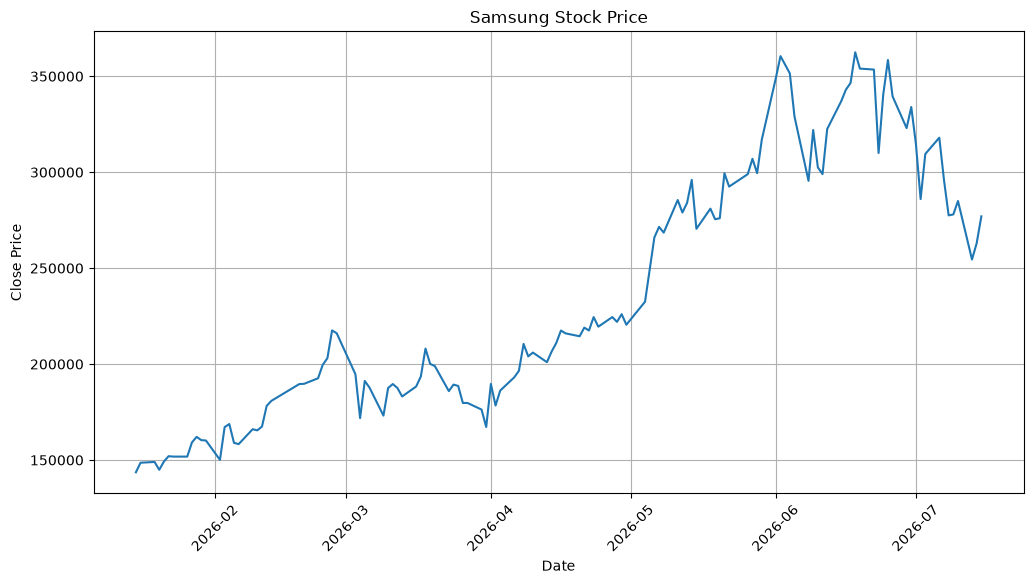

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(samsung["date"], samsung["Close"])

plt.title("Samsung Stock Price")
plt.xlabel("Date")
plt.ylabel("Close Price")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

In [6]:
samsung.to_csv(
    "../data/samsung_stock.csv",
    index=False,
    encoding="utf-8-sig"
)

print("저장 완료!")

저장 완료!


In [7]:
samsung.tail()

,date,Close,High,Low,Open,Volume
117,2026-07-09,278000.0,291500.0,267500.0,288500.0,29703616
118,2026-07-10,285000.0,298000.0,282000.0,291000.0,20088811
119,2026-07-13,254500.0,292500.0,253000.0,285000.0,31882652
120,2026-07-14,263000.0,270000.0,247000.0,255000.0,40086496
121,2026-07-15,277000.0,284500.0,273000.0,283500.0,19693353


In [8]:
import pandas as pd

df = pd.read_csv("../data/samsung_stock.csv")

df.head()

,date,Close,High,Low,Open,Volume
0,2026-01-15,143602.765625,143702.559069,138014.332772,138712.886879,24701126
1,2026-01-16,148592.437500,149191.198162,144001.939095,144999.873531,30000219
2,2026-01-19,148991.609375,150288.924125,146297.186433,146895.947086,22762497
3,2026-01-20,144900.078125,148991.609257,143602.763376,148193.261719,24059218
4,2026-01-21,149191.203125,149490.583466,141507.107713,141606.901160,31703610


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 122 entries, 0 to 121
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    122 non-null    str    
 1   Close   122 non-null    float64
 2   High    122 non-null    float64
 3   Low     122 non-null    float64
 4   Open    122 non-null    float64
 5   Volume  122 non-null    int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 5.8 KB


In [10]:
df.describe()

,Close,High,Low,Open,Volume
count,122.000000,122.000000,122.000000,122.000000,1.220000e+02
mean,235422.921235,241853.519211,229037.837070,235372.137001,3.062679e+07
std,64827.652277,67906.187741,61645.209334,65148.442954,1.061105e+07
min,143602.765625,143702.559069,138014.332772,138712.886879,1.191000e+03
25%,185986.390625,189383.013751,179802.837965,184443.238837,2.290176e+07
50%,216026.406250,218273.826620,210250.000000,214250.000000,3.015979e+07
75%,294750.000000,300375.000000,283125.000000,290875.000000,3.613967e+07
max,362500.000000,374500.000000,352000.000000,372500.000000,8.942795e+07


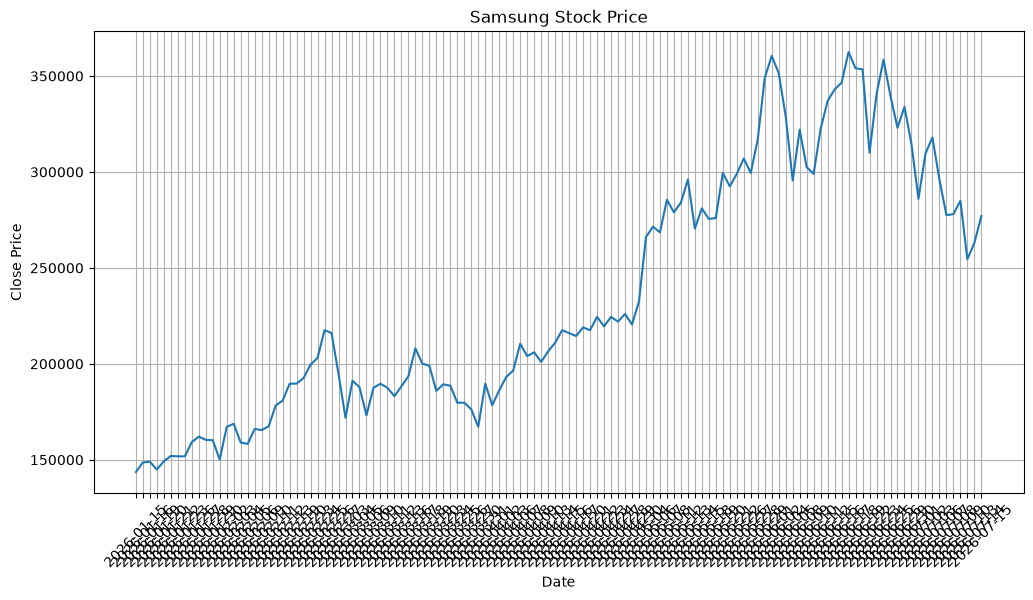

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(df["date"], df["Close"])

plt.title("Samsung Stock Price")
plt.xlabel("Date")
plt.ylabel("Close Price")

plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [12]:
df["return"] = df["Close"].pct_change() * 100

df[["date", "Close", "return"]].head()

,date,Close,return
0,2026-01-15,143602.765625,NaN
1,2026-01-16,148592.437500,3.474635
2,2026-01-19,148991.609375,0.268635
3,2026-01-20,144900.078125,-2.746149
4,2026-01-21,149191.203125,2.961437


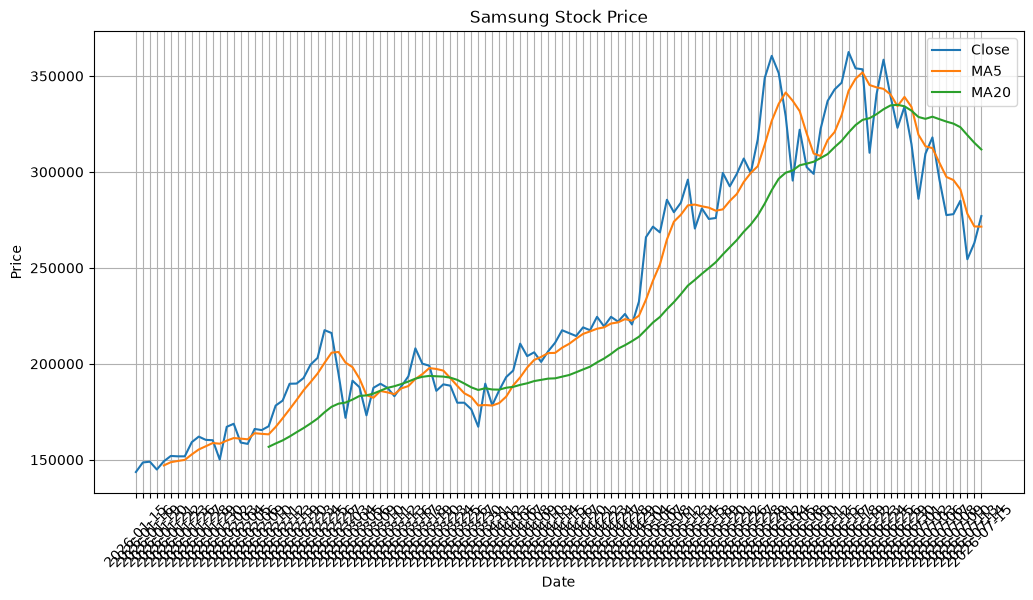

In [13]:
df["MA5"] = df["Close"].rolling(window=5).mean()
df["MA20"] = df["Close"].rolling(window=20).mean()

plt.figure(figsize=(12,6))

plt.plot(df["date"], df["Close"], label="Close")
plt.plot(df["date"], df["MA5"], label="MA5")
plt.plot(df["date"], df["MA20"], label="MA20")

plt.title("Samsung Stock Price")
plt.xlabel("Date")
plt.ylabel("Price")

plt.xticks(rotation=45)

plt.legend()
plt.grid(True)

plt.show()

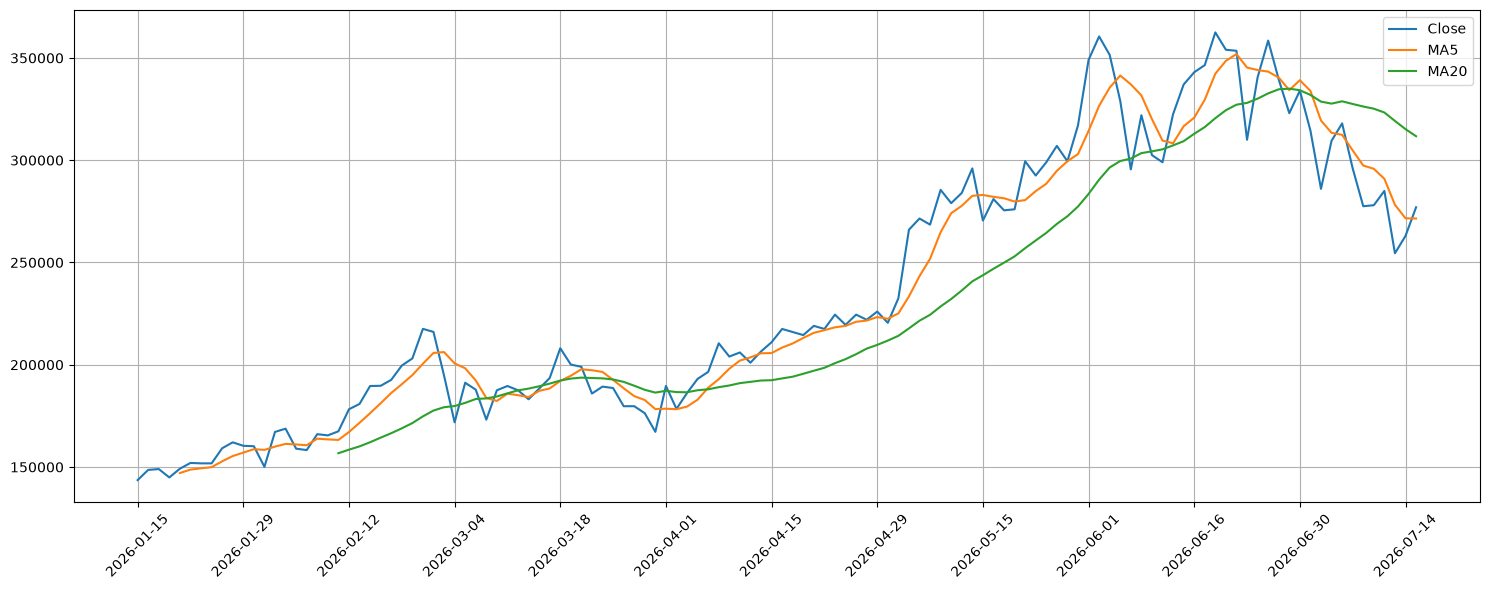

In [14]:
plt.figure(figsize=(15, 6))

plt.plot(df["date"], df["Close"], label="Close")
plt.plot(df["date"], df["MA5"], label="MA5")
plt.plot(df["date"], df["MA20"], label="MA20")

plt.legend()

plt.xticks(df["date"][::10], rotation=45)

plt.grid(True)

plt.tight_layout()

plt.show()